In [19]:
import numpy as np
from scipy.spatial.distance import cdist
import sklearn as sk
import sklearn.datasets as ds
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from PIL import Image
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import os

### Cluster centre update

\begin{equation}
\mathbf{v}_j = \frac{ \sum_{i=1}^N u_{ji}^m \mathbf{x}_i }{ \sum_{i=1}^N u_{ji}^m }
\end{equation}



In [20]:
# Function to update the cluster centres at each iteration
def cluster_update(x, mems, m):
    # x = data matrix, u = membership matrix, m = fuzzifier
    mems_m = mems**m
    new_clusters = mems_m.dot(x.T) / np.atleast_2d(mems_m.sum(axis = 1)).T
    return new_clusters

### Calculating eta(scaling factor for clusters)

In Possibilistic C-Means (PCM), the **scaling parameter** $\eta_j$ controls how distances between data points and cluster centers influence the **membership values**.

The membership of point $x_i$ in cluster $j$ is computed as:

\begin{equation}
\eta_j = \frac{ \sum_{i=1}^N u_{ji}^m \cdot d_{ji}^2 }{ \sum_{i=1}^N u_{ji}^m }

\end{equation}
where:  
- $d_{ji}$ is the distance between point $x_i$ and cluster center $v_j$,  
- $m > 1$ is the fuzzifier that controls the softness of memberships,  
- $\eta_j$ is the cluster-specific scaling factor.

#### Interpretation:

- If $\eta_j$ is **small**, only points **very close** to the center get high membership.
- If $\eta_j$ is **large**, even **distant** points may get moderate membership.

So, $\eta_j$ essentially determines the **spread or region of influence** of cluster $j$.


In [21]:
# Initializing the cluster scaling factors eta
def cluster_scaling_init(mems, m, d):
    # x = data matrix, mems = Memberships, m = Fuzzifier, 
    # centres = Cluster centres
    #print(d.shape) # No. of points x no. of centres
    d_2 = (d**2)
    print(mems.shape) # centres x points
                
    mems_m = mems ** m
    #print(mems_m.dot(d_2).shape)
    #print(np.sum((mems_m*d_2.T), axis = 1).shape)
    #print((np.atleast_2d(mems_m.sum(axis = 1)).T).shape)
    #etas = mems_m.dot(d_2) / np.atleast_2d(mems_m.sum(axis = 1)).T
    etas = np.sum((mems_m*d_2), axis = 1) / (np.atleast_2d(mems_m.sum(axis = 1)).T).flatten()
    print("Etas shape : ",etas.shape)
    return etas

### Possibilistic C-Means (PCM) Membership Update

\begin{equation}
u_{ji} = \frac{1}{1 + \left( \frac{d_{ji}^2}{\eta_j} \right)^{\frac{1}{m-1}} }
\end{equation}


In [22]:
# Function to update membership values for PCM
def PCM_criteria(x, centres, etas, m, metric):
    # x = data, centres = Cluster centers, etas = Cluster scaling params, 
    # m = Fuzzifiers, metric = Distance metric
    d = cdist(x.T, centres, metric = metric)
    #print("Centres : ", centres, centres.shape)
    #print("Etas : ", etas, etas.shape)

    # As a protection, we check for NaNs and replace them with a small epsilon
    d = np.fmax(d, np.finfo(x.dtype).eps)

    d_2 = (d**2) / etas
    d_2 = d_2.T ** (1. / (m-1))

    new_mems = 1. / (1. + d_2)

    # Returning the new memberships and the distances
    return new_mems, d.T

### Fuzzy C-Means (FCM) Membership Update

\begin{equation}
u_{ji} = \frac{ \left( \frac{1}{d_{ji}} \right)^{\frac{2}{m-1}} }{ \sum_{k=1}^c \left( \frac{1}{d_{ki}} \right)^{\frac{2}{m-1}} }
\end{equation}


In [23]:
def FCM_criteria(x, centres, etas, m, metric):
    # x = data, centres = Cluster centers, etas = Cluster scaling params, 
    # m = Fuzzifiers, metric = Distance metric
    #print("FCM crit - centres : ", centres.shape)
    #print("x : ", x.shape)
    d = cdist(x.T, centres, metric = metric).T

    # As a protection, we check for NaNs and replace them with a small epsilon
    d = np.fmax(d, np.finfo(x.dtype).eps)

    d_2 = d ** (-2. / (m-1))

    new_mems = d_2 / np.sum(d_2, axis = 0, keepdims = 1)
    #print(new_mems)

    # Returning the new memberships and the distances
    return new_mems, d

ALgorithm outline :
1. Initiliazing cluster centres randomly
2. Calculating intial memberships,etas using the cluster centres we assumed
3. Running the algo until convergence criterion is met

Convergence if :
   1. The distance between cluster centres in the previous and current iteration is less than a threshold
   2. Max number of iterations reached

In [24]:
def cmeans(x, c, m, t, max_iter, criteria, metric = 'euclidean', c0_in = None, etas = None):
    # x = Data, c = Number of clusters, m = Fuzzifier, t = Threshold for stopping
    # max_iter = Max. iterations to stop, criteria = Decides what type of clustering 
    # metric = Distance measure, c0_in = Initial cluster centers


    # Initial checks to see if data and arguements can be used for clustering
    if (not x.any() or len(x) < 1 or len(x[0]) < 1):
        print("Error : Wrong data format")
        return None

    if (not c or c < 1):
        print("Error : Number of clusters should be at least 1")
        return None
    
    if (not m):
        print("Error : Fuzzifier should be at least 1")
        return None
    
    # Now we know that we can perform clustering on the given data

    # Finding the number of features per data vector and number of data points
    num_feat, num_p = x.shape

    # Randomly initialize cluster centers if not provided
    # Usually, FCM output cluster centres are fed into PCM
    if (c0_in is None):
        # x is of the form SxN, where, S is the number of features in the data vector
        xT = x.T
        c0_in = xT[np.random.choice(xT.shape[0], c, replace = False), :]

    
    # Creating a matrix for storing the cluster centers after each iteration.
    # The below syntax makes a 3D matrix of max_iter number of cxnum_feat arrays.
    centres = np.zeros((max_iter, c, num_feat))
    centres[0] = c0_in

    # Membership matrix that stores the memberships of each point in each of the clusters after each iteration.
    mems = np.zeros((max_iter, c, num_p))

    #print("Etas is ----", etas)
    # Initialize etas if they are not given
    if (etas is None):
        # We use FCM on the initial centres to get an estimate of memberships which are used to find the initial etas
        temp_mems, temp_d = FCM_criteria(x, centres[0], [], m, metric)
        etas = cluster_scaling_init(temp_mems, m, temp_d)
        # We could just make this a ones array as well for all centres to be uniform

    # Initialize a counter to keep track of the number of iterations
    counter = 0

    while (counter < max_iter - 1):

        # Update memberships 
        mems[counter], d = criteria(x, centres[counter], etas, m, metric)

        # Update cluster centres
        centres[counter + 1] = cluster_update(x, mems[counter], m)
        
        # Check if the termination condition is met
        if (np.linalg.norm(centres[counter + 1]  - centres[counter]) < t):
            break

        counter += 1

    # Returning final cluster centres, Initial cluster centres, 
    # final memberships, initial memberships, d and number of iterations

    return centres[counter], centres[0], mems[counter - 1], mems[counter], d, counter, etas

### Extrcting bands
Getting R,G,B bands from the image. Apart from that using the false colour image, NVDI and NWDI are calculated

In [25]:
def extract_bands_and_indices(true_color_path, false_color_path):
    # Opening the true color and false color images
    true_color_img = Image.open(true_color_path)
    false_color_img = Image.open(false_color_path)

    # Converting images to NumPy arrays
    true_color_array = np.array(true_color_img)
    false_color_array = np.array(false_color_img)

    # Extracting red, green, and blue bands from true color image
    red_band = true_color_array[:, :, 0].astype(float)
    green_band = true_color_array[:, :, 1].astype(float)
    blue_band = true_color_array[:, :, 2].astype(float)

    # Extracting infrared (IR) band from false color image
    ir_band = false_color_array[:, :, 0].astype(float)

    # Calculating NDVI (Normalized Difference Vegetation Index)
    denominator_ndvi = ir_band + red_band
    ndvi = np.zeros_like(red_band)
    valid_pixels = denominator_ndvi > 0
    ndvi[valid_pixels] = (ir_band[valid_pixels] - red_band[valid_pixels]) / denominator_ndvi[valid_pixels]

    # Calculating NDWI (Normalized Difference Water Index)
    denominator_ndwi = green_band + ir_band
    ndwi = np.zeros_like(green_band)
    valid_pixels = denominator_ndwi > 0
    ndwi[valid_pixels] = (green_band[valid_pixels] - ir_band[valid_pixels]) / denominator_ndwi[valid_pixels]

    # Stacking all bands and indices into a single array
    combined_data = np.stack([blue_band, green_band, red_band, ir_band, ndvi, ndwi], axis=2)

    # Returning the combined array
    return combined_data


### Extrcting bands(non-satellite)
Getting R,G,B bands from the image

In [26]:
def extract_bands(true_color_path):
    # Opening the true color image
    true_color_img = Image.open(true_color_path)
    
    # Converting the image to a NumPy array
    true_color_array = np.array(true_color_img)

    # Extracting the red, green, and blue bands from the true color image
    red_band = true_color_array[:, :, 0].astype(float)
    green_band = true_color_array[:, :, 1].astype(float)
    blue_band = true_color_array[:, :, 2].astype(float)

    # Stacking the extracted bands into a combined array
    combined_data = np.stack([blue_band, green_band, red_band], axis=2)

    # Returning the combined array with the bands
    return combined_data


### The Silhouette Index (SI) for a point is given by:

\begin{equation}
s = \frac{b - a}{\max(a, b)}
\end{equation}

where:
- $ a$  is the intra-cluster distance: the average distance from the point to other points in the same cluster.
   
- $ b$ is the nearest-cluster distance: the minimum distance from the point to the center of the nearest different cluster.


### The Davies–Bouldin Index (DBI) is defined as:

$$
\text{DBI} = \frac{1}{c} \sum_{i=1}^{c} \max_{j \ne i} \left( \frac{S_i + S_j}{M_{ij}} \right)
$$

where:

- $c$ is the number of clusters.
- $S_i$ is the average intra-cluster distance for cluster $i$:
$$
S_i = \frac{1}{|C_i|} \sum_{x \in C_i} \|x - \mu_i\|
$$
- $M_{ij}$ is the distance between cluster centers $\mu_i$ and $\mu_j$:
$$
M_{ij} = \|\mu_i - \mu_j\|
$$


### Dunn Index

\begin{equation}
     \text{Dunn Index}= \frac{\min_{1 \leq i < j \leq n} d(i, j)}{\max_{1 \leq k \leq c} \delta(k)}
\end{equation}

where:
 - $ d(i, j) $ is the distance between points $ i $ and $ j $ from different clusters
 - $ \delta(k) $ is the maximum distance between points within the same cluster $ k $ (intra-cluster distance)

### RMSE

  \begin{equation}
\text{RMSE} = \sqrt{ \frac{1}{N} \sum_{i=1}^{N} \left\| x_i - c_{k(i)} \right\|^2 }
\end{equation}

where:
 - $x_i$: $i^{\text{th}}$ data point  
 - $c_{k(i)}$: Center of the cluster to which $x_i$ belongs  
 - $N$: Total number of data points
### Xie-Beni Index

\begin{equation}
\text{XBI} = \frac{ \displaystyle \sum_{i=1}^{N} \sum_{k=1}^{c} \mu_{ki}^m \left\| x_i - c_k \right\|^2 }{ N \cdot \displaystyle \min_{\substack{j,k=1 \\ j \neq k}}^{c} \left\| c_j - c_k \right\|^2 }
\end{equation}

Where:
- $\mu_{ki}$: Membership of point $x_i$ to cluster $k$  
- $m$: Fuzzifier 
- $c_k$: Center of cluster $k$  
- $c$: Total number of clusters  
- $N$: Number of data points


In [27]:
def cluster_quality_modified(x, c, centres, m, mems, labels=None):
    # Assigning each data point to the cluster with the highest membership value
    cl_out = np.argmax(mems, axis=0)
    
    # Initializing Root Mean Square Error accumulator
    RMSE_ = 0
    
    # Initializing silhouette scores array
    silhouettes = np.zeros(x.shape[0])
    
    # Identifying non-empty clusters
    valid_clusters = [i for i in range(c) if np.sum(cl_out == i) > 0]
    
    counti = 0

    # Computing simplified silhouette scores for each point
    for i in valid_clusters:
        x_c = x[cl_out == i]
        centre_c = centres[i]
        for x_ci in x_c:
            # Calculating intra-cluster distance
            a_i = np.linalg.norm(x_ci - centre_c)
            RMSE_ += a_i ** 2
            
            # Calculating nearest inter-cluster distance
            centres_mod = np.delete(centres, i, axis=0) - x_ci
            dists = np.sum(centres_mod ** 2, axis=1)
            b_i = np.sqrt(np.min(dists))
            
            # Calculating simplified silhouette coefficient
            simp_sil = (b_i - a_i) / max(b_i, a_i)
            silhouettes[counti] = simp_sil
            counti += 1

    # Calculating median silhouette score
    sil_score = np.median(silhouettes)
    print("Median silhouette score is:", sil_score)

    # Computing average intra-cluster distances
    intra_clus_d = np.zeros(c)
    for i in valid_clusters:
        x_c = x[cl_out == i]
        if x_c.shape[0] == 0:
            continue
        centre_c = centres[i]
        dists = np.linalg.norm(x_c - centre_c, axis=1)
        intra_clus_d[i] = np.mean(dists)

    # Initializing Davies-Bouldin Index (DBI) and minimum inter-cluster distance
    DBI = 0
    interclus_min = float('inf')

    # Calculating DBI and minimum inter-cluster distance
    for j in valid_clusters:
        dbi_j = 0
        for k in valid_clusters:
            if k != j:
                # Measuring distance between cluster centers
                d_jk = np.linalg.norm(centres[j] - centres[k])
                interclus_min = min(interclus_min, d_jk)
                dbi_jk = (intra_clus_d[j] + intra_clus_d[k]) / d_jk
                dbi_j = max(dbi_j, dbi_jk)
        DBI += dbi_j

    # Averaging the DBI over all valid clusters
    DBI = DBI / len(valid_clusters)
    print("Davies-Bouldin Index is:", DBI)

    # Calculating Dunn Index as ratio of min inter-cluster to max intra-cluster distance
    DI = interclus_min / np.max(intra_clus_d[valid_clusters])
    print("Dunn Index is:", DI)

    # Finalizing RMSE by taking the square root of average squared distance
    RMSE_ = np.sqrt(RMSE_ / x.shape[0])
    print("RMSE is:", RMSE_)

    # Initializing Xie-Beni Index
    xbi = 0
    mems_m = mems ** m

    # Accumulating weighted distances using membership degrees
    for i, x_ci in enumerate(x):
        dists = np.sum((centres - x_ci) ** 2, axis=1)
        xbi += np.sum(mems_m[:, i] * dists)

    # Finalizing Xie-Beni Index
    xbi = xbi / (x.shape[0] * interclus_min)
    print("Xie-Beni Index is:", xbi)

    # Returning all clustering quality metrics
    q = [sil_score, DBI, DI, RMSE_, xbi]
    return q


### Running the algorithm(Satellite images)
Here both true an false colour images are required



In [28]:
def run_algo_satellite(img_name, save_folder, true_color_path, false_color_path, m, t, max_iter, a, b, threshold=0):
    # Creating the folder to save results if it does not exist
    if not os.path.exists(save_folder):
        os.makedirs(save_folder)

    # Extracting spectral bands and indices (e.g., NDVI, NDWI) from the input images
    combined = extract_bands_and_indices(true_color_path, false_color_path)
    h, w, d = combined.shape

    # Reshaping the image data to (features, samples) format for clustering
    x = combined.reshape(-1, d).T

    # Extracting NDVI and NDWI from the respective bands
    ndvi = combined[:, :, 4]
    ndwi = combined[:, :, 5]

    # Initializing a list to store clustering quality metrics
    quals = []

    # Looping through different numbers of clusters
    for num_clusters in range(a, b):
        # Performing PCM clustering
        cents, cents_in, mems, mems_in, dist, num_iter, etas = cmeans(
            x, num_clusters, m, t, max_iter, PCM_criteria, 'euclidean'
        )

        # Assigning cluster labels based on highest membership values
        cluster_labels = np.argmax(mems, axis=0)

        # Assigning -1 to low-confidence pixels based on threshold
        cluster_labels[mems.max(axis=0) <= threshold] = -1

        # Reshaping cluster labels back to the image shape
        cluster_labels = cluster_labels.reshape(h, w)

        print(np.unique(cluster_labels))  # Printing the unique labels for verification

        # Creating subplots for visualization
        fig, ax = plt.subplots(2, 3, figsize=(30, 12))

        # Displaying the original true color image
        true_color_img = Image.open(true_color_path)
        ax[0, 0].imshow(true_color_img)
        ax[0, 0].set_title('Original Image')
        ax[0, 0].axis('off')

        # Displaying the false color image
        false_color_img = Image.open(false_color_path)
        ax[0, 1].imshow(false_color_img)
        ax[0, 1].set_title('False Image')
        ax[0, 1].axis('off')

        # Displaying the NDVI map
        ax[0, 2].imshow(ndvi, cmap='RdYlGn')
        ax[0, 2].set_title('NDVI (Normalized Difference Vegetation Index)')
        ax[0, 2].axis('off')

        # Displaying the NDWI map
        ax[1, 0].imshow(ndwi, cmap='Blues')
        ax[1, 0].set_title('NDWI (Normalized Difference Water Index)')
        ax[1, 0].axis('off')

        # Identifying valid cluster labels (excluding unassigned -1)
        valid_clusters = sorted([label for label in np.unique(cluster_labels) if label != -1])
        num_clusters_in_labels = len(valid_clusters)
        print(f"Number of clusters (after threshold): {num_clusters_in_labels}")

        # Choosing a color map based on number of clusters
        base_colors = plt.cm.tab10.colors if num_clusters_in_labels <= 10 else plt.cm.tab20.colors

        # Preparing color mapping based on presence of unassigned clusters
        if -1 in cluster_labels:
            all_colors = [(0, 0, 0)] + [base_colors[i] for i in valid_clusters]
            label_to_color_index = {cluster: idx + 1 for idx, cluster in enumerate(valid_clusters)}
            remapped_labels = np.full_like(cluster_labels, fill_value=0)
        else:
            all_colors = [base_colors[i] for i in valid_clusters]
            label_to_color_index = {cluster: idx for idx, cluster in enumerate(valid_clusters)}
            remapped_labels = np.full_like(cluster_labels, fill_value=-1)

        # Remapping cluster labels to color indices
        for cluster, color_idx in label_to_color_index.items():
            remapped_labels[cluster_labels == cluster] = color_idx

        # Creating a ListedColormap for visualization
        cmap = ListedColormap(all_colors)

        # Creating legend handles for display
        handles = [mpatches.Patch(color='black', label='Unassigned')] if -1 in cluster_labels else []
        handles += [
            mpatches.Patch(color=cmap(label_to_color_index[c]), label=f'Cluster {c}')
            for c in valid_clusters
        ]

        # Displaying the clustered image with legend
        im = ax[1, 1].imshow(remapped_labels, cmap=cmap)
        ax[1, 1].set_title(f'Clustered Image (PCM) - {num_clusters_in_labels} Clusters')
        ax[1, 1].axis('off')
        ax[1, 1].legend(handles=handles, loc='lower right', title='Clusters', fontsize='small', title_fontsize='medium')

        # Hiding the final subplot (unused)
        ax[1, 2].axis('off')
        plt.tight_layout()

        # Saving the visualized cluster image
        filename = os.path.join(save_folder, f"{img_name}_clusters{num_clusters}.png")
        plt.savefig(filename, bbox_inches='tight', dpi=300)

        # Calculating clustering quality metrics
        ele = cluster_quality_modified(x.T, num_clusters, cents, m, mems, [])
        quals.append(ele)

    # Printing all clustering quality results
    print(quals)

    # Defining metric names and axis labels
    metric_names = ['Silhouette Score', 'Davies-Bouldin Index', 'Dunn Index', 'RMSE', 'Xie-Beni Index']
    ylabels = ['Score (↑)', 'Index (↓)', 'Index (↑)', 'Error (↓)', 'Index (↓)']

    # Plotting clustering quality metrics
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    quals = np.array(quals)
    k_values = range(a, b)
    for i in range(5):
        axes[i].plot(k_values, quals[:, i], marker='o', linestyle='-')
        axes[i].set_title(metric_names[i])
        axes[i].set_xlabel('Number of clusters')
        axes[i].set_ylabel(ylabels[i])
        axes[i].set_xticks(k_values)
        axes[i].set_xticklabels(k_values)
        axes[i].grid(True)

    plt.tight_layout()

    # Saving the metrics plot
    filename = os.path.join(save_folder, f"metrics_{img_name}.png")
    plt.savefig(filename, bbox_inches='tight', dpi=300)



### Running the algorithm(Non-satellite images)
Here only true version is required

In [29]:
def run_algo_normal(img_name, save_folder, true_color_path, m, t, max_iter, a, b, threshold=0):
    if not os.path.exists(save_folder):
        os.makedirs(save_folder)  # Creating output folder if not already existing

    combined = extract_bands(true_color_path)  # Extracting band data from the image
    h, w, d = combined.shape  # Getting image dimensions
    x = combined.reshape(-1, d).T  # Reshaping image for clustering

    quals = []  # Initializing quality metric list for storing

    for num_clusters in range(a, b):  # Looping through number of clusters
        # Applying PCM clustering
        cents, cents_in, mems, mems_in, dist, num_iter, etas = cmeans(x, num_clusters, m, t, max_iter, PCM_criteria, 'euclidean')

        # Getting cluster assignments based on maximum membership
        cluster_labels = np.argmax(mems, axis=0)

        # Assigning -1 to low-confidence pixels based on thresholding
        cluster_labels[mems.max(axis=0) <= threshold] = -1

        # Getting maximum membership per pixel for checking
        max_mems = mems.max(axis=0)

        # Finding indices with confidence below thresholding
        low_confidence_indices = max_mems <= threshold

        # Printing membership values below thresholding
        print("Membership values less than or equal to threshold:")
        print(max_mems[low_confidence_indices])

        # Reshaping cluster labels to original image dimensions for displaying
        cluster_labels = cluster_labels.reshape(h, w)

        print(np.unique(cluster_labels))  # Showing unique labels for verifying

        fig, ax = plt.subplots(1, 2, figsize=(30, 12))  # Creating figure for plotting

        # Plotting original image for comparison viewing
        true_color_img = Image.open(true_color_path)
        ax[0].imshow(true_color_img)
        ax[0].set_title('Original Image')
        ax[0].axis('off')

        # Plotting clustering result
        valid_clusters = sorted([label for label in np.unique(cluster_labels) if label != -1])

        num_clusters_in_labels = len(valid_clusters)
        print(f"Number of clusters (after threshold): {num_clusters_in_labels}")

        # Choosing colormap depending on number of clusters for mapping
        if num_clusters_in_labels <= 10:
            base_colors = plt.cm.tab10.colors
        else:
            base_colors = plt.cm.tab20.colors  # Choosing extended color range if needed

        # Handling color assignment for unassigned pixels
        if -1 in cluster_labels:
            all_colors = [(0, 0, 0)] + [base_colors[i] for i in valid_clusters]
            label_to_color_index = {cluster: idx + 1 for idx, cluster in enumerate(valid_clusters)}
            remapped_labels = np.full_like(cluster_labels, fill_value=0)
        else:
            all_colors = [base_colors[i] for i in valid_clusters]
            label_to_color_index = {cluster: idx for idx, cluster in enumerate(valid_clusters)}
            remapped_labels = np.full_like(cluster_labels, fill_value=-1)

        # Remapping labels for color indexing
        for cluster, color_idx in label_to_color_index.items():
            remapped_labels[cluster_labels == cluster] = color_idx

        cmap = ListedColormap(all_colors)  # Creating colormap for displaying

        # Creating legend patches for labeling
        if -1 in cluster_labels:
            handles = [mpatches.Patch(color='black', label='Unassigned')]
        else:
            handles = []
        handles += [mpatches.Patch(color=cmap(label_to_color_index[c]), label=f'Cluster {c}')
                    for c in valid_clusters]

        # Displaying clustered image with color legend
        im = ax[1].imshow(remapped_labels, cmap=cmap)
        ax[1].set_title(f'Clustered Image (PCM) - {num_clusters_in_labels} Clusters')
        ax[1].axis('off')
        ax[1].legend(handles=handles, loc='lower right', title='Clusters', fontsize='small', title_fontsize='medium')

        plt.tight_layout()  # Optimizing layout for saving

        # Saving clustered image for archiving
        filename = os.path.join(save_folder, f"{img_name}_clusters{num_clusters}.png")
        plt.savefig(filename, bbox_inches='tight', dpi=300)

        # Calculating clustering quality metrics for comparing
        ele = cluster_quality_modified(x.T, num_clusters, cents, m, mems, [])
        quals.append(ele)

    print(quals)  # Printing quality metrics for tracking

    # Preparing metric names and y-axis labels for plotting
    metric_names = ['Silhouette Score', 'Davies-Bouldin Index', 'Dunn Index', 'RMSE', 'Xie-Beni Index']
    ylabels = ['Score (↑)', 'Index (↓)', 'Index (↑)', 'Error (↓)', 'Index (↓)']

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))  # Creating subplots for metrics plotting

    quals = np.array(quals)
    k_values = range(a, b)
    for i in range(5):
        axes[i].plot(k_values, quals[:, i], marker='o', linestyle='-')  # Plotting each metric
        axes[i].set_title(metric_names[i])
        axes[i].set_xlabel('Number of clusters')
        axes[i].set_ylabel(ylabels[i])
        axes[i].set_xticks(k_values)
        axes[i].set_xticklabels(k_values)
        axes[i].grid(True)

    plt.tight_layout()  # Adjusting layout before saving
    filename = os.path.join(save_folder, f"metrics_{img_name}.png")
    plt.savefig(filename, bbox_inches='tight', dpi=300)  # Saving quality plot for documenting


### UI CODE
1. The following parameters are obtained the user:min number of clusters,max number of clusters,fuzzifier,threshold and maximum number of iterations
2. The user can choose to cluster a satellite image or a non-satellite image
3. Based on the option chosen the user is propmted to choose the files required
4. After this an output folder is chosen by the user and the name to be menetioned in the names of output files is also obtained
5. The results are displayed on a new window
     

In [30]:
import tkinter as tk
from tkinter import filedialog, messagebox, simpledialog, Canvas, Scrollbar, Frame
from PIL import Image, ImageTk


(4, 807984)
Etas shape :  (4,)
[-1  0  1  2  3]
Number of clusters (after threshold): 4
Median silhouette score is: 0.011392616548415667
Davies-Bouldin Index is: 20.511088059709998
Dunn Index is: 0.03149321636747837
RMSE is: 31.999813546877153
Xie-Beni Index is: 254.91448800117647
[[0.011392616548415667, 20.511088059709998, 0.03149321636747837, 31.999813546877153, 254.91448800117647]]


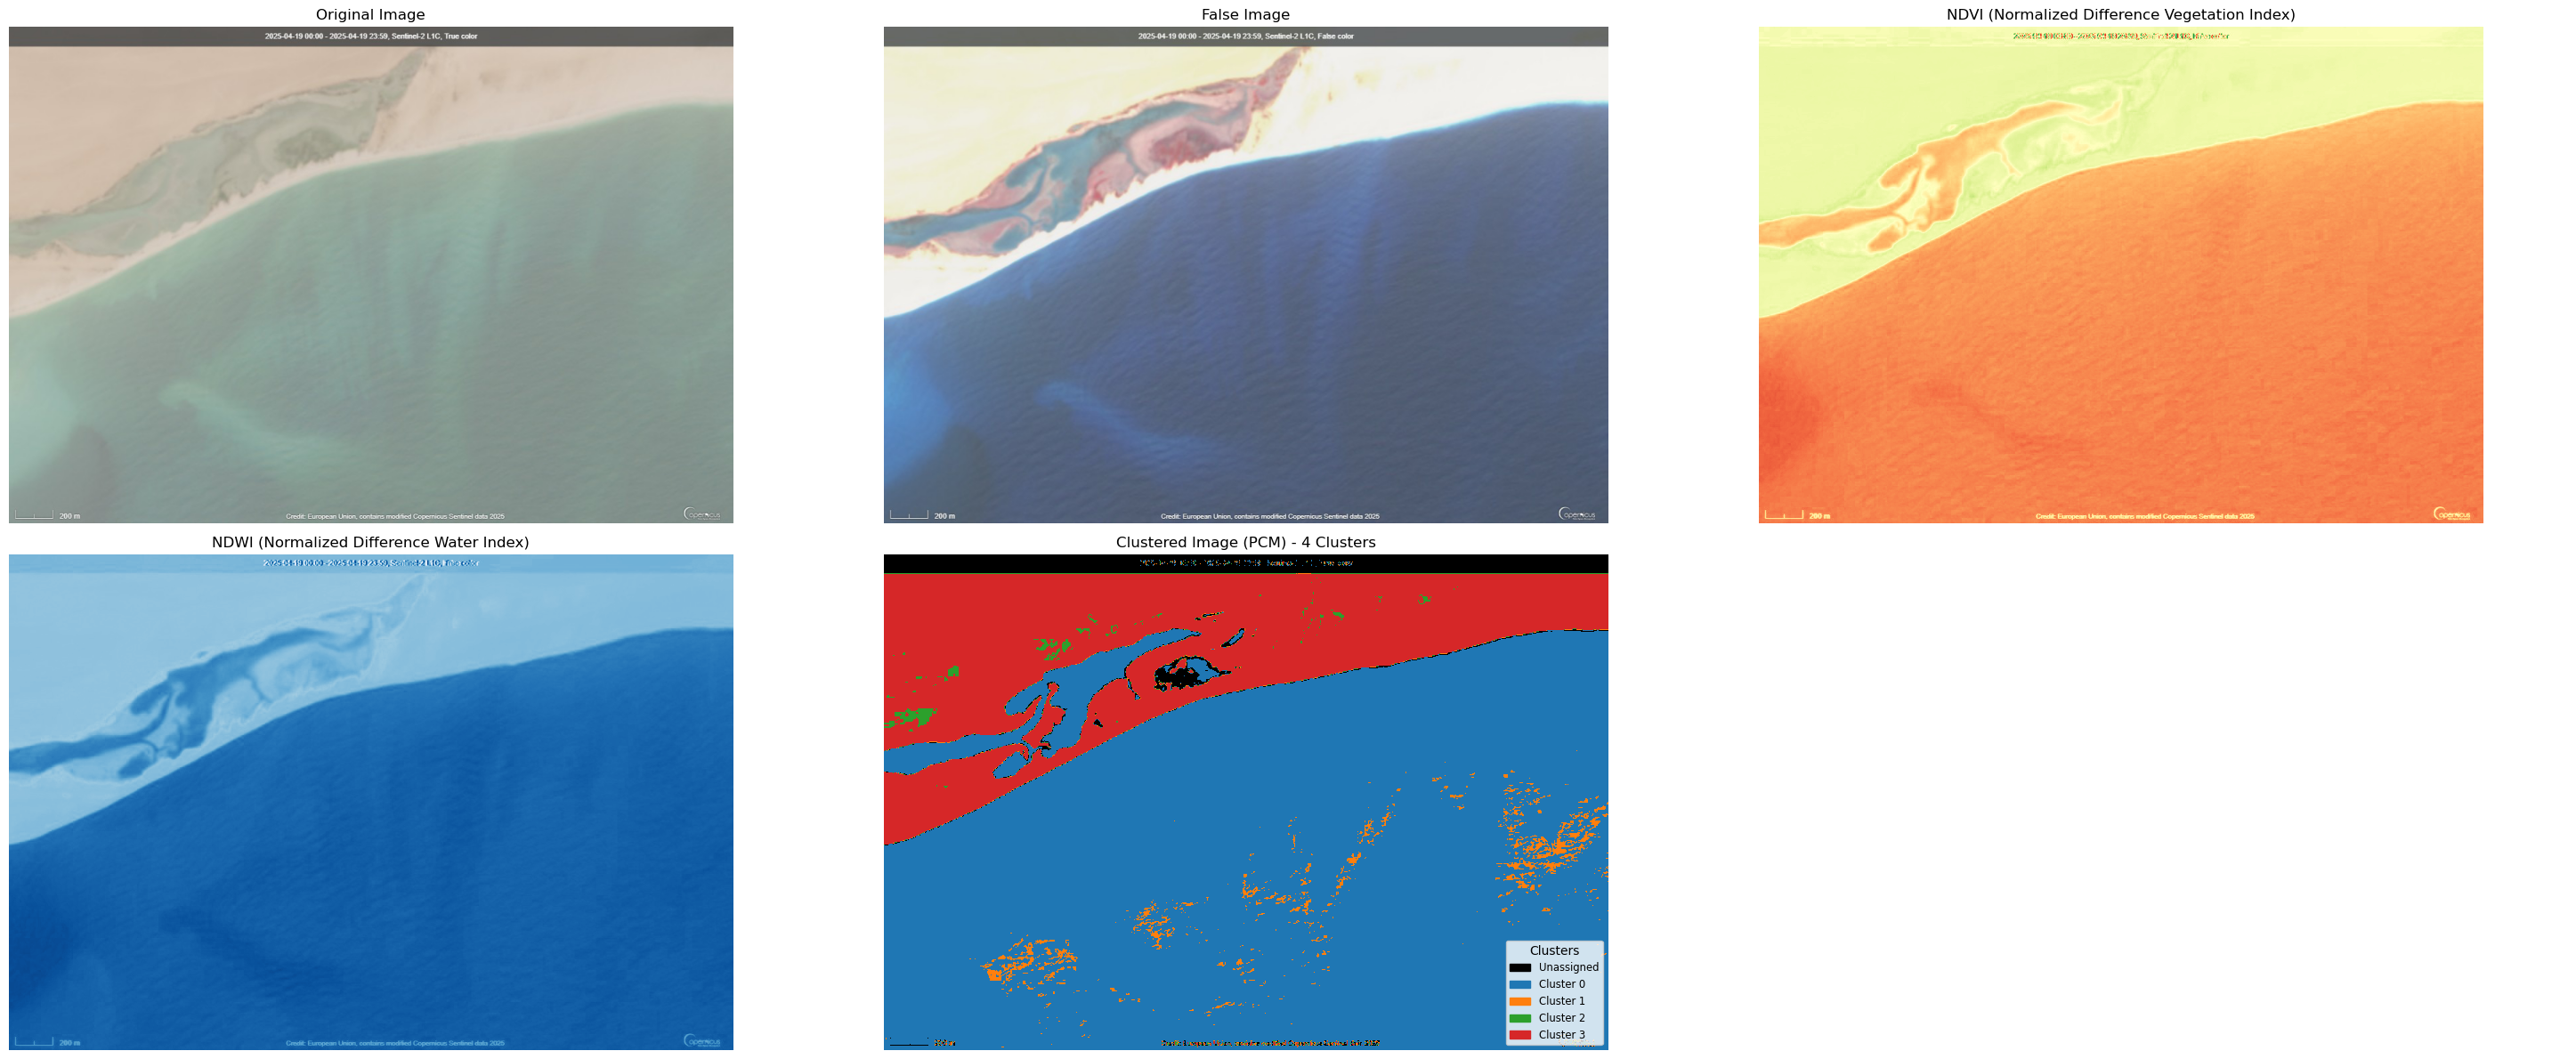

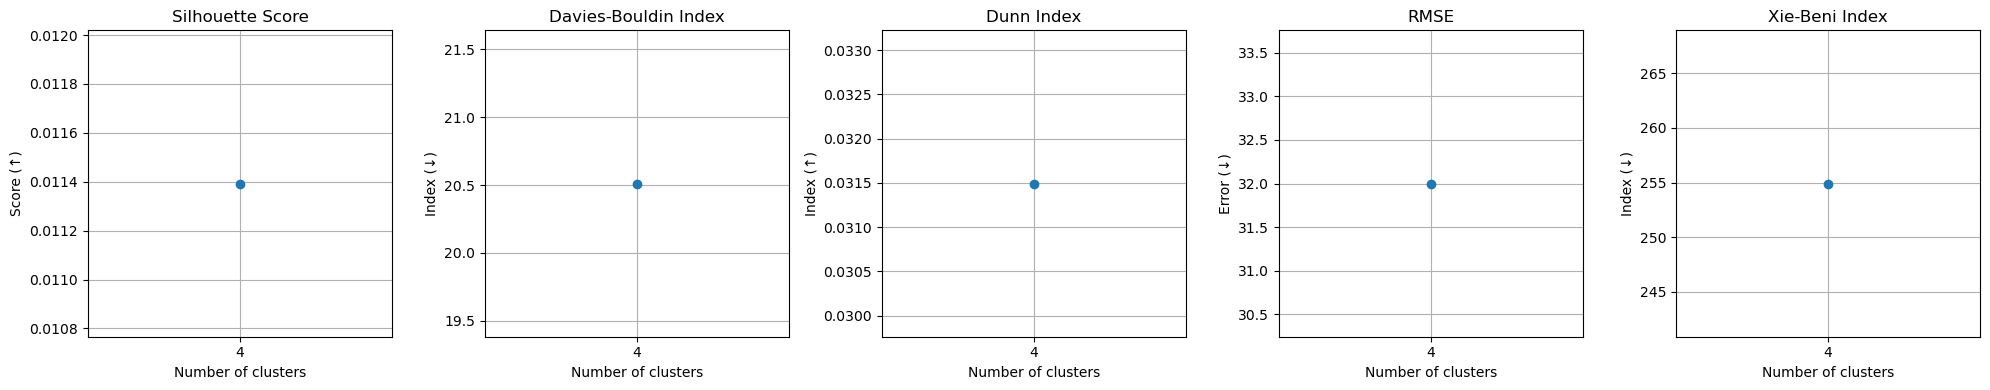

In [ ]:
# Setting convergence threshold for stopping iterations
conv_thresh = 0.005

# Defining supported image extensions for filtering
IMAGE_EXTS = ('.png', '.jpg', '.jpeg', '.bmp', '.gif')

# Initializing mode for choosing image type (satellite or normal) during uploading
mode = None

# Defining function for displaying all images in a selected folder using scrolling
def show_all_images(folder_path):
    # Collecting valid image paths by checking extensions and confirming existence
    image_paths = [os.path.join(folder_path, f)
                   for f in os.listdir(folder_path)
                   if f.lower().endswith(IMAGE_EXTS) and os.path.isfile(os.path.join(folder_path, f))]

    # Handling empty folder by showing alert and returning
    if not image_paths:
        messagebox.showinfo("No Images", "No images found in selected folder.")
        return

    # Creating viewer window for displaying images
    viewer = tk.Tk()
    viewer.title("Images in Output Folder")

    # Creating canvas and scrollbar for enabling scrolling
    canvas = Canvas(viewer)
    scrollbar = Scrollbar(viewer, orient="vertical", command=canvas.yview)
    scrollable_frame = Frame(canvas)

    # Binding configure event to update scroll region dynamically
    scrollable_frame.bind(
        "<Configure>",
        lambda e: canvas.configure(scrollregion=canvas.bbox("all"))
    )

    # Creating window for packing frame inside canvas and enabling vertical scrolling
    canvas.create_window((0, 0), window=scrollable_frame, anchor="nw")
    canvas.configure(yscrollcommand=scrollbar.set)

    # Looping through all image paths for opening and displaying
    for path in image_paths:
        try:
            img = Image.open(path)
            img.thumbnail((1000, 1000))  # Resizing image for fitting
            img_tk = ImageTk.PhotoImage(img)

            # Creating label for holding image and packing it
            lbl = tk.Label(scrollable_frame, image=img_tk)
            lbl.image = img_tk  # Saving reference to avoid garbage collection
            lbl.pack(padx=10, pady=10)
        except Exception as e:
            print(f"Could not open {path}: {e}")  # Logging failure while opening

    # Packing canvas and scrollbar to viewer for completing layout
    canvas.pack(side="left", fill="both", expand=True)
    scrollbar.pack(side="right", fill="y")
    viewer.mainloop()

# Creating dictionary to store GUI parameter fields for later accessing
params = {}

# Defining helper function for creating labeled entry fields in GUI for typing
def create_param_field(label_text):
    lbl = tk.Label(root, text=label_text)
    lbl.pack()
    entry = tk.Entry(root)
    entry.pack()
    return entry

# Defining function for collecting and validating parameters from GUI before processing
def get_params():
    try:
        return {
            'min_clusters': int(params['min_clusters'].get()),
            'max_clusters': int(params['max_clusters'].get()) + 1,  # Adding 1 for including upper limit while looping
            'fuzzifier': float(params['fuzzifier'].get()),          # Setting fuzzifier m for weighting
            'threshold': float(params['threshold'].get()),          # Setting membership threshold for pruning
            'iterations': int(params['iterations'].get())           # Defining iteration count for repeating
        }
    except ValueError:
        messagebox.showerror("Invalid Input", "Please enter valid numeric values.")  # Handling invalid typing
        return None

# Handling user submission by calling parameter extraction before uploading
def upload_file_with_params():
    param_values = get_params()
    if param_values is None:
        return
    upload_file_with_custom_params(param_values)

# Handling image upload and path collection based on selected mode for proceeding
def upload_file_with_custom_params(param_values):
    global root
    if mode == 'satellite':
        # Prompting user for selecting true color image before continuing
        messagebox.showinfo("Choose image", "Please choose the true colour version of your image")
        true_color_path = filedialog.askopenfilename(title="Select True Color Image",
                                                     filetypes=[("Image files", "*.png;*.jpg;*.jpeg;*.bmp;*.gif")])
        if not true_color_path:
            return

        # Prompting user for selecting false color image before continuing
        messagebox.showinfo("Choose image", "Please choose the false colour version of your image")
        false_color_path = filedialog.askopenfilename(title="Select False Color Image",
                                                      filetypes=[("Image files", "*.png;*.jpg;*.jpeg;*.bmp;*.gif")])
        if not false_color_path:
            return

    elif mode == 'normal':
        # Prompting user for selecting only one image for normal processing
        messagebox.showinfo("Choose image", "Please choose your image")
        true_color_path = filedialog.askopenfilename(title="Select Image",
                                                     filetypes=[("Image files", "*.png;*.jpg;*.jpeg;*.bmp;*.gif")])
        if not true_color_path:
            return
        false_color_path = None  # Skipping second image when working in normal mode

    else:
        # Showing error if mode has not been set properly before running
        messagebox.showerror("Error", "Invalid mode selected.")
        return

    # Prompting user to choose folder for saving output image
    messagebox.showinfo("Next Step", "Please choose the output folder")
    output_folder = filedialog.askdirectory(title="Select Folder to Save Result")
    if not output_folder:
        return

    # Asking user for naming the output image before saving
    output_name = simpledialog.askstring("Input", "Enter a name for the output image:", parent=root)
    if not output_name:
        return

    # Destroying GUI before running processing function
    root.destroy()

    # Calling the correct processing algorithm based on mode for running
    if mode == 'satellite':
        run_algo_satellite(output_name, output_folder, true_color_path, false_color_path,
                           param_values['fuzzifier'], conv_thresh, param_values['iterations'],
                           param_values['min_clusters'], param_values['max_clusters'], param_values['threshold'])

    elif mode == 'normal':
        run_algo_normal(output_name, output_folder, true_color_path,
                        param_values['fuzzifier'], conv_thresh, param_values['iterations'],
                        param_values['min_clusters'], param_values['max_clusters'], param_values['threshold'])

    # Showing output folder images after finishing
    show_all_images(output_folder)

# Defining button handler for selecting satellite mode and proceeding
def select_satellite_mode():
    global mode
    mode = 'satellite'
    upload_file_with_params()

# Defining button handler for selecting normal mode and proceeding
def select_normal_mode():
    global mode
    mode = 'normal'
    upload_file_with_params()

# Creating GUI root window and initializing basic layout for starting
root = tk.Tk()
root.title("Image Processing Tool")
root.geometry("300x450")

# Creating entry fields for accepting parameters before processing
params['min_clusters'] = create_param_field("Min Clusters")
params['max_clusters'] = create_param_field("Max Clusters")
params['fuzzifier'] = create_param_field("fuzzifier")
params['threshold'] = create_param_field("Threshold for Membership")
params['iterations'] = create_param_field("Number of Iterations")

# Creating buttons for selecting image type and proceeding
sat_button = tk.Button(root, text="Satellite Image", command=select_satellite_mode)
sat_button.pack(pady=10)

normal_button = tk.Button(root, text="Normal Image", command=select_normal_mode)
normal_button.pack(pady=10)

# Running the GUI loop for keeping the interface active and listening
root.mainloop()
